# Chebyshev Policies and the Mountain Car Problem: Reinforcement Learning for Low-dimensional Control Tasks
## REINFORCE utilizing MLP approximators
  
Using REINFORCE: Can MLP approximators achieve similar results as Chebyshev approximators?  
In this notebook, we utilize network sizes with parameter counts comparable to the ones of CH-3.  

Version 2.0  
Date: 2026-01-29   
Current version: hannes.unger@fh-salzburg.ac.at  

## Imports and Definitions

In [ ]:
import torch
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
from itertools import repeat
from utils import parallel
from pickleshare import PickleShareDB
from matplotlib import colors as mcolors
from algorithms import polynomial_agents

db = PickleShareDB('./picklesharedb')

%load_ext autoreload
%autoreload 2

In [3]:
def get_best_candidates_of_training_result(results, optimizer_list, n_runs):
    best_index = {}
    for i in range(len(optimizer_list)):
        valid_results = []
        for j in range(n_runs):
            # Check if the element is a list and has the structure we're looking for
            if isinstance(results[i][j], list) and len(results[i][j]) > 1:
                valid_results.append((j, results[i][j][1][-1])) # take only last reward
        2
        if valid_results:  # Only proceed if there are valid results
            best_index[i] = max(valid_results, key=lambda x: x[1])[0]
        else:
            print(f'Finding index: No converging result for optimizer {i}')
            # Optionally skip optimizers with no valid results

    best_coeffs = []
    to_delete = []

    for index in best_index:
        try:
            best_coeffs.append(results[index][best_index[index]][-1])
        except:
            print(f'Adding coeffs: No converging result for optimizer {index}, removing entry')
            to_delete.append(index)
    
    for i in to_delete:
        del best_index[i]
    
    print(f'{best_index}\n{len(best_index)}\n{len(best_coeffs)}')

    return best_index, best_coeffs

In [4]:
def get_mean_rewards_from_training_results(results, optimizer_list, n_runs, window_size=5):
    results_mean_rewards = []
    for i in range(len(optimizer_list)):
        results_mean_rewards.append(np.mean(np.array([results[i][j][1] for j in range(n_runs) if isinstance(results[i][j], list)]), axis=0)) # skip rows where nan values lead to exception instead of list
    
    # moving average for n_runs for optimizer
    results_moving_average_rewards = []

    for i in range(len(optimizer_list)):
        results_moving_average_rewards.append(np.convolve(results_mean_rewards[i], np.ones(window_size), mode='valid') / window_size)
    
    return results_mean_rewards, results_moving_average_rewards

In [5]:
def get_mean_rewards_from_evaluation_results(results, n_runs, best_indices, window_size=5):
    results_mean_rewards = []
    to_delete = []
    for i in range(len(results)):
        try:
            results_mean_rewards.append(np.mean(np.array([results[i][j] for j in range(n_runs)]), axis=0)) 
        except:
            print(f'Calculate Mean: No converging result for optimizer {i}, removing entry')
            to_delete.append(i)

    for i in to_delete:
        del best_indices[i]

    # moving average for n_runs for optimizer
    window_size=5
    results_moving_average_rewards = []

    for i in range(len(results)):
        try:
            results_moving_average_rewards.append(np.convolve(results_mean_rewards[i], np.ones(window_size), mode='valid') / window_size)
        except:
            pass
    
    return results_mean_rewards, results_moving_average_rewards

In [6]:
def get_converging_coeffs_of_training_results(results, optimizer_list, n_runs):
    coeffs = []

    for i, opt_result in enumerate(results):
        coeffs.append([])
        for j in range(n_runs):
            try:
                coeffs[i].append(opt_result[j][-1])
            except:
                print(f'Adding coeffs: No converging result for optimizer {i}')

    to_delete = []

    for i in range(0, len(coeffs)):
        if len(coeffs[i]) == 0:
            to_delete.append(i)

    coeffs = [val for i, val in enumerate(coeffs) if i not in to_delete]
    optimizer_list = [val for i, val in enumerate(optimizer_list) if i not in to_delete]
    return coeffs, optimizer_list

In [7]:
def plot_evaluation_rewards(results, optimizers, window_size=5, axes=None):
    reinforce_results_eval_optimizers_mean_rewards = []
    for i in range(len(results)):
        reinforce_results_eval_optimizers_mean_rewards.append(np.mean(np.array([results[i][j] for j in range(len(results[i]))]), axis=0)) 

    # moving average for n_runs for optimizer
    window_size=5
    reinforce_results_eval_optimizers_moving_average_rewards = []

    for i in range(len(results)):
        reinforce_results_eval_optimizers_moving_average_rewards.append(np.convolve(reinforce_results_eval_optimizers_mean_rewards[i], np.ones(window_size), mode='valid') / window_size)

    if axes is None:
        fig, axes = plt.subplots(4, 3) 
        axes = axes.flatten()
        fig.set_figwidth(len(optimizers)*3)
        fig.set_figheight(20)
        fig.suptitle(f'Rewards over episodes with different optimizers')

    for i, opt in enumerate(optimizers):
        ax = axes[i]
        ax.set_title(f'{opt}')
        for j in range(len(results[i])):   
            ax.plot(results[i][j], alpha=0.3)
            ax.set_ylim([-100, 100])
        ax.plot(reinforce_results_eval_optimizers_moving_average_rewards[i], 'k', label='moving average')

In [8]:
def plot_evaluation_min_mean_max_rewards(results, optimizers, window_size=5, color='r', label=None, axes=None, axes_indices=None, coeffs_in_results=False):
    if axes_indices == None:
        raise Exception('Need axis object and index information.')
    
    # mean rewards
    reinforce_results_eval_optimizers_min_rewards = []
    reinforce_results_eval_optimizers_mean_rewards = []
    reinforce_results_eval_optimizers_max_rewards = []
    for i in range(len(results)):
        if coeffs_in_results:
            reinforce_results_eval_optimizers_mean_rewards.append(np.mean(np.array([results[i][j][1] for j in range(len(results[i]))]), axis=0)) 
            reinforce_results_eval_optimizers_min_rewards.append(np.min(np.array([results[i][j][1] for j in range(len(results[i]))]), axis=0)) 
            reinforce_results_eval_optimizers_max_rewards.append(np.max(np.array([results[i][j][1] for j in range(len(results[i]))]), axis=0))     
        else:
            reinforce_results_eval_optimizers_mean_rewards.append(np.mean(np.array([results[i][j] for j in range(len(results[i]))]), axis=0)) 
            reinforce_results_eval_optimizers_min_rewards.append(np.min(np.array([results[i][j] for j in range(len(results[i]))]), axis=0)) 
            reinforce_results_eval_optimizers_max_rewards.append(np.max(np.array([results[i][j] for j in range(len(results[i]))]), axis=0)) 

    # moving average for n_runs for optimizer
    reinforce_results_eval_optimizers_moving_average_rewards = []

    for i in range(len(results)):
        reinforce_results_eval_optimizers_moving_average_rewards.append(np.convolve(reinforce_results_eval_optimizers_mean_rewards[i], np.ones(window_size), mode='valid') / window_size)

    for i, opt in enumerate(optimizers):
        ax = axes[axes_indices[opt]]
        ax.set_title(f'{opt}')        
        ax.plot(reinforce_results_eval_optimizers_max_rewards[i], color, alpha=0.5)
        ax.plot(reinforce_results_eval_optimizers_min_rewards[i], color, alpha=0.5)
        ax.plot(reinforce_results_eval_optimizers_mean_rewards[i], color, label=label)
        ax.fill_between(x=range(len(reinforce_results_eval_optimizers_max_rewards[i])), y1=reinforce_results_eval_optimizers_min_rewards[i], y2=reinforce_results_eval_optimizers_max_rewards[i], color=color, alpha=0.1)
        ax.set_ylim([-100, 100])
        ax.legend(loc="best")

In [9]:
def plot_training_rewards(results, all_optimizers, title=None, window_size=5):
    n_runs = len(results[0])
    episodes = len(results[0][0][1])

    _, reinforce_results_train_optimizers_moving_average_rewards = get_mean_rewards_from_training_results(results, all_optimizers, n_runs, window_size=5)

    fig, axes = plt.subplots(5, (len(all_optimizers)+2)//4) 
    axes = axes.flatten()
    fig.set_figwidth(len(all_optimizers)*3)
    fig.set_figheight(20)
    if not title:
        fig.suptitle(f'Rewards over episodes with different optimizers, {episodes} episodes, {n_runs} runs')
    else:
        fig.suptitle(title)

    for i, _ in enumerate(all_optimizers):
        ax = axes[i]
        ax.set_title("%s" % all_optimizers[i])
        for result in results[i]:
            try:
                ax.plot(result[1], alpha=0.3)
                ax.set_ylim([-200, 100])
            except:
                pass
        ax.plot(reinforce_results_train_optimizers_moving_average_rewards[i], 'k', label=f'mean reward (with moving average n={n_runs})')
        ax.legend(loc="best")

In [10]:
def boxplot_training_rewards(results, all_optimizers, title=None, axes=None, label=None):
    if axes is None:
        raise Exception('Need axis object.')
    
    for i, _ in enumerate(all_optimizers):
        ax = axes[i]
        ax.set_title("%s" % all_optimizers[i])
        for result in results[i]:
            try:
                ax.boxplot(result[1], label=label)
                ax.set_ylim([-200, 100])
            except:
                pass
        ax.legend(loc="best")

In [11]:
def plot_training_min_mean_max_rewards(results, all_optimizers, color='r', label=None, axes=None):
    n_runs = len(results[0])
    episodes = len(results[0][0][1])

    results_mean_rewards = []
    results_min_rewards = []
    results_max_rewards = []
    for i in range(len(all_optimizers)):
        try:
            results_mean_rewards.append(np.mean(np.array([results[i][j][1] for j in range(n_runs) if isinstance(results[i][j], list)]), axis=0)) # skip rows where nan values lead to exception instead of list
        except:
            results_mean_rewards.append(np.nan)
        try:
            results_min_rewards.append(np.min(np.array([results[i][j][1] for j in range(n_runs) if isinstance(results[i][j], list)]), axis=0)) 
        except:
            results_min_rewards.append(np.nan)
        try:    
            results_max_rewards.append(np.max(np.array([results[i][j][1] for j in range(n_runs) if isinstance(results[i][j], list)]), axis=0)) 
        except:
            results_max_rewards.append(np.nan)


    if axes is None:
        fig, axes = plt.subplots(5, (len(all_optimizers)+2)//4) 
        axes = axes.flatten()
        fig.set_figwidth(len(all_optimizers)*3)
        fig.set_figheight(20)
        fig.suptitle(f'Rewards over episodes with different optimizers, {episodes} episodes, {n_runs} runs')

    for i, _ in enumerate(all_optimizers):
        try:
            ax = axes[i]
            ax.set_title("%s" % all_optimizers[i])
            ax.plot(results_min_rewards[i], color, alpha=0.5)
            ax.plot(results_max_rewards[i], color, alpha=0.5)
            ax.plot(results_mean_rewards[i], color, label=label)
            ax.fill_between(x=range(len(results_min_rewards[i])), y1=results_min_rewards[i], y2=results_max_rewards[i], color=color, alpha=0.1)
            ax.set_ylim([-200, 100])
            ax.legend(loc="best")
        except:
            pass

In [12]:
def get_best_candidates_of_evaluation_result(evaluation_results):
    max_mean = float('-inf')
    outer_index = -1
    inner_index = -1

    for i, outer in enumerate(evaluation_results):
        for j, inner in enumerate(outer):
            #mean_value = sum(inner) / len(inner)  # Compute mean of current inner list
            mean_value = np.mean(inner[1])
            if mean_value > max_mean:
                max_mean = mean_value
                outer_index = i
                inner_index = j

    print(f"The optimizer index with the highest mean is: {outer_index}")
    print(f"The corresponding policy index is: {inner_index}")

    return outer_index, inner_index

# Multilayer perceptrons (MLP) Approximator

For our polynomial approximators in the previous notebook, we define that for an $n$-dimensional polynomial of _max-degree_ $d$, we train $(d+1)^n$ parameters.  
We performed our first round of experiments with an approximator of max-degree $3$.  
For the $n=2$ dimensional observation space, this implies $16$ parameters.  
  
To have an MLP approximator of comparable size, we also start small and utilize one input, one output and one hidden layer.  
We utilize sigmoid activation functions.  
Given a large enough number of sigmoid units in its single hidden layer, a feedforward neural network can theoretically approximate any continuous function in the input space to an arbitrary degree of accuracy [[1](https://web.njit.edu/~usman/courses/cs675_fall18/10.1.1.441.7873.pdf)].  
So, theoretically, we have the same "quality" approximator as with our Chebyshev Basis introduced earlier.  
  
The total number of parameters in a feedforward (means, no feedback connections) network is given by the number of interconnections:  
\
$n_{total}=n_{input} \cdot n_{hidden} + n_{hidden} \cdot n_{output} + n_{hidden} + n_{output}$  
  
The first two products resemble connections between input nodes with nodes of the hidden layer as well as connections between output nodes with nodes of the hidden layer, respectively.  
The last two summands resemble bias: Each previous layer connects to the next layer with a bias node to every non-bias node of the next layer.  

Taken from: [[2](https://towardsdatascience.com/number-of-parameters-in-a-feed-forward-neural-network-4e4e33a53655)]:  
<img width="300" alt="image" src="https://miro.medium.com/v2/resize:fit:750/format:webp/1*osFo5MLmWLXE5rCOvwIiIA.png">  


In [15]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size, bias=True),
            nn.Sigmoid(),
            nn.Linear(hidden_size, output_size, bias=True)
        )

    def forward(self, x):
        return self.layers(x)

    def count_parameters(self, model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Initialize weights and biases such that the output is a constant value
    def initialize_to_constant(self, constant_value):
        with torch.no_grad():
            # Set all weights to zero (to ignore the inputs)
            for layer in self.layers:
                if isinstance(layer, nn.Linear):
                    layer.weight.fill_(0.0)  # Set all weights to 0
                    if layer.out_features == 1:  # Output layer (last Linear)
                        layer.bias.fill_(constant_value)  # Set bias to constant value
                    else:
                        layer.bias.fill_(0.0)  # Set bias of hidden layer to 0 for no impact

In [16]:
# Example values for input, hidden, and output sizes
input_size = 2
output_size = 1
hidden_size = 4  # You can change this to control the number of parameters

# Create the model
model = MLP(input_size, hidden_size, output_size)

# Print total number of parameters
total_params = model.count_parameters(model)
print(f"Total number of parameters: {total_params}")

Total number of parameters: 17


To set $\sigma$ to a constant value, we manually set the bias to a constant value and initialize the weights with small random numbers.   

In [13]:
model.initialize_to_constant(0.25)
model(torch.randn(1, input_size)).item()

0.25

### Some tests without parallelization

In [101]:
n_input_nodes=2
n_hidden_nodes=4
n_output_nodes=1
alpha_mu=0.0003
alpha_sigma=0.00003
episodes=100
discount=0.9 # discount=1.0 diverges for sigma approximator
initial_sigma=0.25 # The higher, the more initial exploration

In [ ]:
env = gym.make("MountainCarContinuous-v0", render_mode='human')
reinforce_trainable_mrp_mlp_17 = polynomial_agents.TrainableContinuousMRPWrapper(env, basis='mlp',
                                                                                    initial_sigma=initial_sigma,
                                                                                    normalize_observations=False,
                                                                                    initialization='constant',
                                                                                    mlp_n_hidden_nodes=n_hidden_nodes,
                                                                                    mlp_n_input_nodes=n_input_nodes,
                                                                                    mlp_n_output_nodes=n_output_nodes)
obs = reinforce_trainable_mrp_mlp_17.reset()[0]

In [100]:
reinforce_rewards = []
reinforce_steps = []
reinforce_loss = []
_, _, _ = reinforce_trainable_mrp_mlp_17.train(alpha_mu=alpha_mu, alpha_sigma=alpha_sigma, epochs=episodes, discount=discount,
                                                            method='reinforce_autodiff',
                                                            learning_history=reinforce_rewards,
                                                            steps_history=reinforce_steps,
                                                            loss_history=reinforce_loss, mu_optimizer='radam', sigma_optimizer='radam')

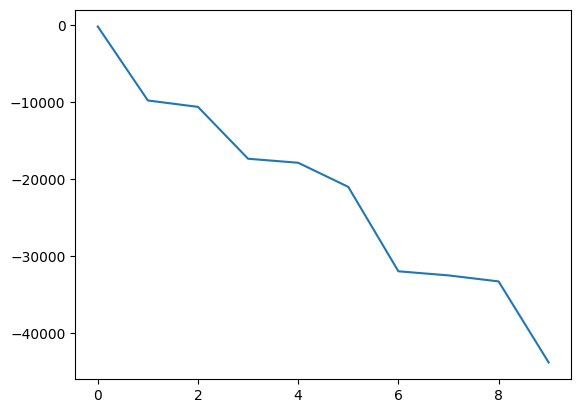

In [102]:
plt.plot(reinforce_rewards)

In [104]:
# Run some actions from trained policy
obs = reinforce_trainable_mrp_mlp_17.reset()[0]
for i in range(600):
    reinforce_trainable_mrp_mlp_17.render()
    obs, reward, terminated, truncated, info, action, _ = reinforce_trainable_mrp_mlp_17.step(obs)  
    if terminated:
        s = reinforce_trainable_mrp_mlp_17.reset()

In [ ]:
mrp = polynomial_agents.TrainableContinuousMRPWrapper(env, basis='mlp', 
                                                                normalize_observations=True,
                                                                initial_sigma=0.25,
                                                                mu_coeffs=reinforce_trainable_mrp_mlp_17.agent.mu_approximator.model.state_dict())      
mrp.agent.mu_approximator.model.state_dict()

In [ ]:
kwargs = {'alpha_mu': alpha_mu, 'alpha_sigma': alpha_sigma, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce_autodiff', 'normalize_observations': True, 
          'approximator': 'mlp', 'mlp_n_hidden_nodes': n_hidden_nodes, 'mlp_n_input_nodes': n_input_nodes, 'mlp_n_output_nodes': n_output_nodes}

test_result = parallel.job_reinforce_train(kwargs)

### Parallel training runs

In [18]:
n_input_nodes=2
n_hidden_nodes=4
n_output_nodes=1
alpha_mu=0.0003
alpha_sigma=0.00003
episodes=100
discount=0.9 # discount=1.0 diverges for sigma approximator
initial_sigma=0.25 # The higher, the more initial exploration

In [ ]:
kwargs = {'alpha_mu': alpha_mu, 'alpha_sigma': alpha_sigma, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce_autodiff', 'normalize_observations': True, 
          'approximator': 'mlp', 'mlp_n_hidden_nodes': n_hidden_nodes, 'mlp_n_input_nodes': n_input_nodes, 'mlp_n_output_nodes': n_output_nodes}

n_runs = 5
args = [kwargs for i in range(n_runs)]

with mp.Pool(processes=n_runs) as pool:
    reinforce_trainable_mrp_mlp_17_results = pool.map(parallel.job_reinforce_train, args)

# Permanently store results
db['reinforce_trainable_mrp_mlp_17_results'] = reinforce_trainable_mrp_mlp_17_results

In [ ]:
reinforce_trainable_mrp_mlp_17_results = db['reinforce_trainable_mrp_mlp_17_results']
best_index_autodiff_results = max(enumerate(reinforce_trainable_mrp_mlp_17_results), key=lambda x: x[1][0])[0]
reinforce_trainable_mrp_mlp_17 = polynomial_agents.TrainableContinuousMRPWrapper(env, basis='mlp', normalize_observations=True, initial_sigma=initial_sigma, mu_coeffs=reinforce_trainable_mrp_mlp_17_results[best_index_autodiff_results][-1], sigma_coeffs=reinforce_trainable_mrp_mlp_17_results[best_index_autodiff_results][-2])
obs = reinforce_trainable_mrp_mlp_17.reset()[0]

Text(0.5, 1.0, 'Adam: Cumulated reward over episodes, best result out of 5 runs')

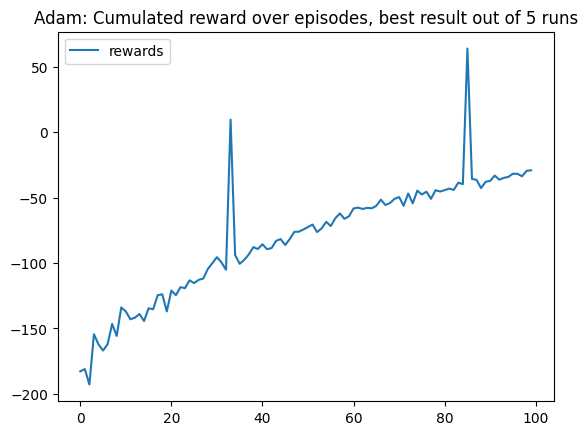

In [21]:
plt.plot(reinforce_trainable_mrp_mlp_17_results[best_index_autodiff_results][1], label='rewards')
plt.legend(loc='best')
plt.title(f'Adam: Cumulated reward over episodes, best result out of {n_runs} runs')

Text(0.5, 1.0, 'Adam: Cumulated reward over episodes, mean result over 5 runs\nTotal: -8319.15908002385')

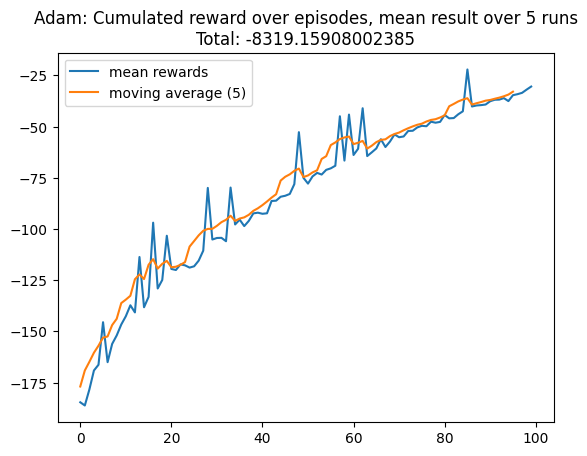

In [22]:
reinforce_trainable_mrp_mlp_17_mean_results = np.mean([m[1] for m in reinforce_trainable_mrp_mlp_17_results], axis=0)
window_size=5
reinforce_trainable_mrp_mlp_17_moving_average_results = np.convolve(reinforce_trainable_mrp_mlp_17_mean_results, np.ones(window_size), mode='valid') / window_size

plt.plot(reinforce_trainable_mrp_mlp_17_mean_results, label='mean rewards')
plt.plot(reinforce_trainable_mrp_mlp_17_moving_average_results, label=f'moving average ({window_size})')
plt.legend(loc='best')
plt.title(f'Adam: Cumulated reward over episodes, mean result over {n_runs} runs\nTotal: {np.sum(reinforce_trainable_mrp_mlp_17_mean_results)}')

In [23]:
# # Run some actions from trained policy
# obs = reinforce_trainable_mrp_mlp_17.reset()[0]
# for i in range(1000):
#     reinforce_trainable_mrp_mlp_17.render()
#     obs, reward, terminated, truncated, info, action, _ = reinforce_trainable_mrp_mlp_17.step(obs)  
#     if terminated:
#         s = reinforce_trainable_mrp_mlp_17.reset()

### Interpretation

While the mean reward increases steadily, indicating that the training process per se works,  
evaluating the best result shows that the car does not manage to reach the goal flag.  

## Training and evaluation with available optimizers

In [22]:
# Required mlp sizes
n_input_nodes = 2
n_output_nodes = 1

# 17 parameters
n_hidden_nodes_1 = 4
# 33 parameters
n_hidden_nodes_2 = 8
# 65 parameters
n_hidden_nodes_3 = 16

n_input_nodes = 2
n_hidden_nodes = 4
n_output_nodes = 1
alpha_mu = 0.0003
alpha_sigma = 0.00003
episodes = 100
discount = 0.9 # discount=1.0 diverges for sigma approximator
initial_sigma = 0.25 # The higher, the more initial exploration
n_runs = 20

color_cheby = mcolors.CSS4_COLORS['steelblue']
color_mlp_17 = mcolors.CSS4_COLORS['burlywood']
color_mlp_33 = mcolors.CSS4_COLORS['mediumpurple']
color_mlp_65 = mcolors.CSS4_COLORS['indianred']

optimizers = ['adam', 'adam-amsgrad', 'adamw', 'adamw-amsgrad', 'adamax', 'lbfgs', 'nadam', 'radam', 'rmsprop', 'rprop', 'sgd-momentum', 'sgd-nesterov']
kwargs_mlp_17 = {'mode': 'optimizers', 'alpha_mu': alpha_mu, 'alpha_sigma': alpha_sigma, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce_autodiff', 'normalize_observations': True, 'n_runs': n_runs,
          'approximator': 'mlp', 'mlp_n_hidden_nodes': n_hidden_nodes_1, 'mlp_n_input_nodes': n_input_nodes, 'mlp_n_output_nodes': n_output_nodes}
kwargs_mlp_33 = {'mode': 'optimizers', 'alpha_mu': alpha_mu, 'alpha_sigma': alpha_sigma, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce_autodiff', 'normalize_observations': True, 'n_runs': n_runs,
          'approximator': 'mlp', 'mlp_n_hidden_nodes': n_hidden_nodes_2, 'mlp_n_input_nodes': n_input_nodes, 'mlp_n_output_nodes': n_output_nodes}
kwargs_mlp_65 = {'mode': 'optimizers', 'alpha_mu': alpha_mu, 'alpha_sigma': alpha_sigma, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce_autodiff', 'normalize_observations': True, 'n_runs': n_runs,
          'approximator': 'mlp', 'mlp_n_hidden_nodes': n_hidden_nodes_3, 'mlp_n_input_nodes': n_input_nodes, 'mlp_n_output_nodes': n_output_nodes}

In [ ]:
# # Test function call
# #parallel.job_reinforce_optimizers(optimizers[7], kwargs)

# kwargs = {'mode': 'optimizers', 'alpha_mu': alpha_mu, 'alpha_sigma': alpha_sigma, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce_autodiff', 'normalize_observations': True, 'n_runs': n_runs,
#           'approximator': 'mlp', 'mlp_n_hidden_nodes': n_hidden_nodes, 'mlp_n_input_nodes': n_input_nodes, 'mlp_n_output_nodes': n_output_nodes, 'mu_optimizer': 'sgd', 'sigma_optimizer': 'sgd'}

# parallel.job_reinforce_train(kwargs=kwargs)

In [ ]:
pool = parallel.NestablePool(n_runs)
reinforce_results_train_optimizers_mlp_17 = pool.starmap(parallel.job_reinforce_optimizers, zip(optimizers, repeat(kwargs_mlp_17)))
# Storing variables
db['reinforce_results_train_optimizers_mlp_17'] = reinforce_results_train_optimizers_mlp_17

In [ ]:
pool = parallel.NestablePool(n_runs)
reinforce_results_train_optimizers_mlp_33 = pool.starmap(parallel.job_reinforce_optimizers, zip(optimizers, repeat(kwargs_mlp_33)))
# Storing variables
db['reinforce_results_train_optimizers_mlp_33'] = reinforce_results_train_optimizers_mlp_33

In [ ]:
pool = parallel.NestablePool(n_runs)
reinforce_results_train_optimizers_mlp_65 = pool.starmap(parallel.job_reinforce_optimizers, zip(optimizers, repeat(kwargs_mlp_65)))
# Storing variables
db['reinforce_results_train_optimizers_mlp_65'] = reinforce_results_train_optimizers_mlp_65

In [ ]:
reinforce_results_train_optimizers_mlp_17 = db['reinforce_results_train_optimizers_mlp_17']
reinforce_results_train_optimizers_mean_rewards_mlp_17, reinforce_results_train_optimizers_moving_average_rewards_mlp_17 = get_mean_rewards_from_training_results(reinforce_results_train_optimizers_mlp_17, optimizers, n_runs)

reinforce_results_train_optimizers_mlp_33 = db['reinforce_results_train_optimizers_mlp_33']
reinforce_results_train_optimizers_mean_rewards_mlp_33, reinforce_results_train_optimizers_moving_average_rewards_mlp_33 = get_mean_rewards_from_training_results(reinforce_results_train_optimizers_mlp_33, optimizers, n_runs)

reinforce_results_train_optimizers_mlp_65 = db['reinforce_results_train_optimizers_mlp_65']
reinforce_results_train_optimizers_mean_rewards_mlp_65, reinforce_results_train_optimizers_moving_average_rewards_mlp_65 = get_mean_rewards_from_training_results(reinforce_results_train_optimizers_mlp_65, optimizers, n_runs)

reinforce_results_train_optimizers = db['reinforce_results_train_optimizers']
reinforce_results_train_optimizers_mean_rewards, reinforce_results_train_optimizers_moving_average_rewards = get_mean_rewards_from_training_results(reinforce_results_train_optimizers, optimizers, n_runs)

reinforce_results_train_optimizers_deg5 = db['reinforce_results_train_optimizers_deg5']
reinforce_results_train_optimizers_mean_rewards_deg5, reinforce_results_train_optimizers_moving_average_rewards_deg5 = get_mean_rewards_from_training_results(reinforce_results_train_optimizers_deg5, optimizers, n_runs)

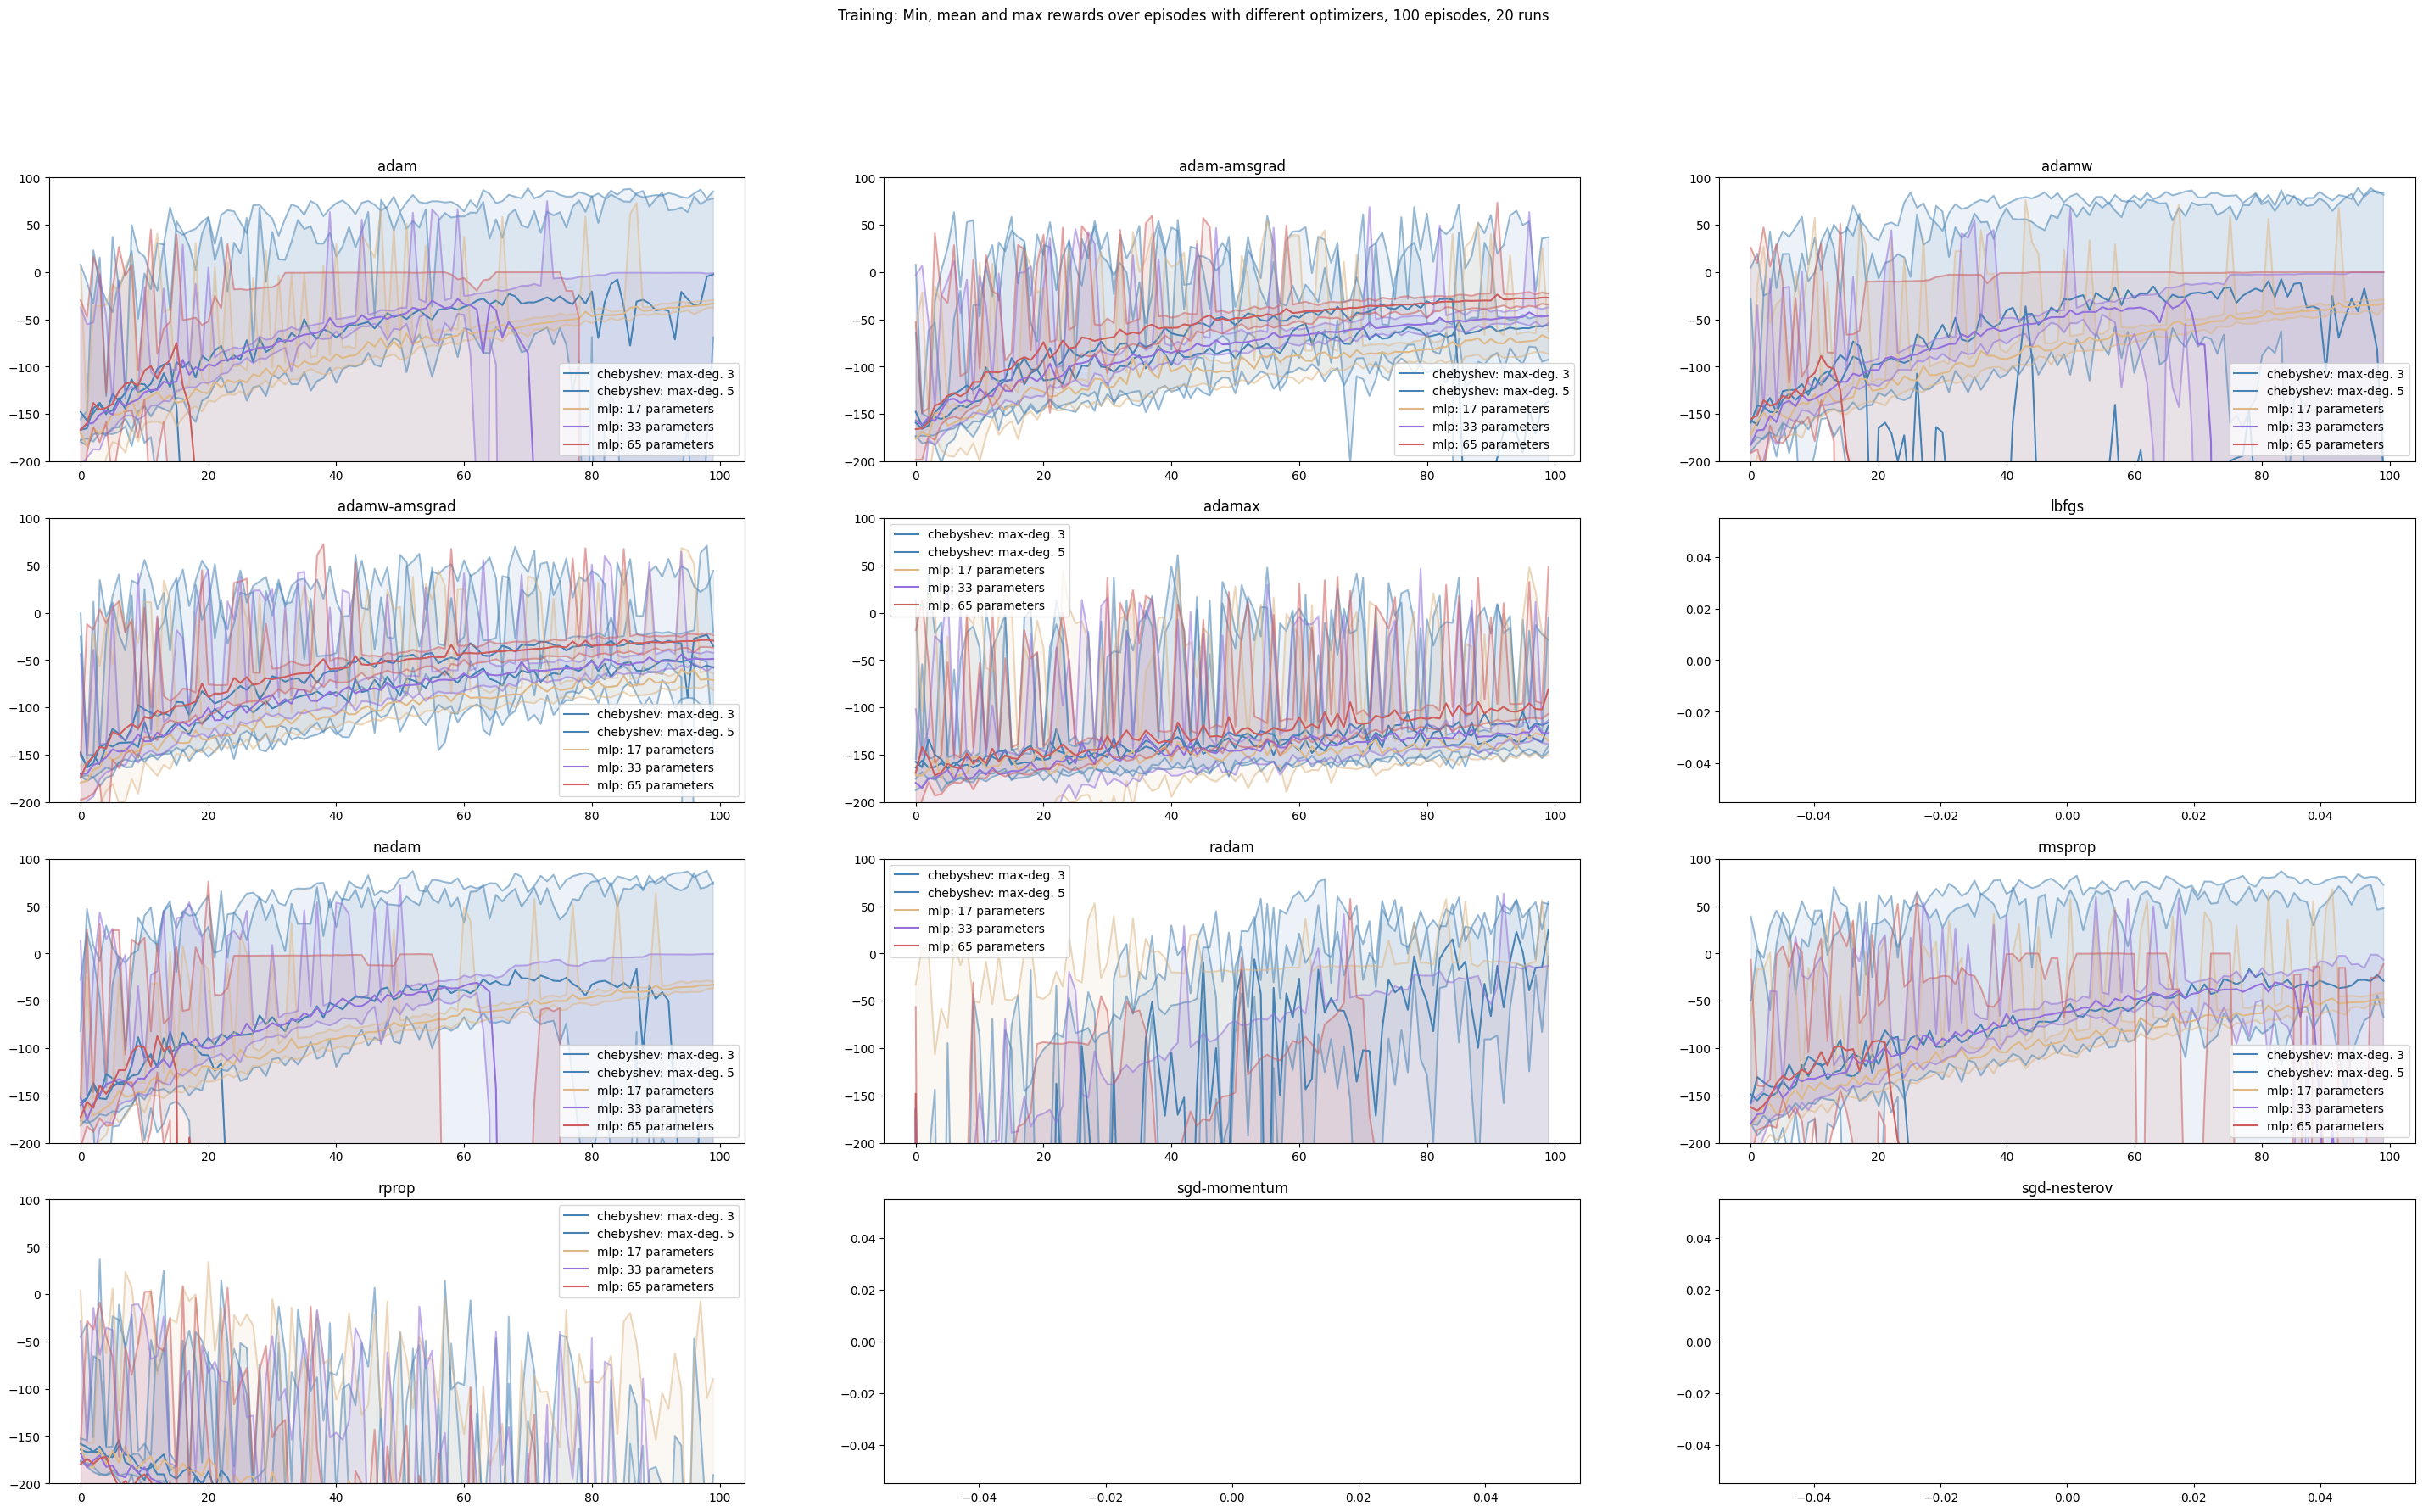

In [15]:
fig, axes = plt.subplots(4, (len(optimizers)+2)//4) 
axes = axes.flatten()
fig.set_figwidth(len(optimizers)*3)
fig.set_figheight(20)
fig.suptitle(f'Training: Min, mean and max rewards over episodes with different optimizers, {episodes} episodes, {n_runs} runs')

plot_training_min_mean_max_rewards(reinforce_results_train_optimizers, optimizers, color=color_cheby, label='chebyshev: max-deg. 3', axes=axes)
plot_training_min_mean_max_rewards(reinforce_results_train_optimizers_deg5, optimizers, color=color_cheby, label='chebyshev: max-deg. 5', axes=axes)
plot_training_min_mean_max_rewards(reinforce_results_train_optimizers_mlp_17, optimizers, color=color_mlp_17, label='mlp: 17 parameters', axes=axes)
plot_training_min_mean_max_rewards(reinforce_results_train_optimizers_mlp_33, optimizers, color=color_mlp_33, label='mlp: 33 parameters', axes=axes)
plot_training_min_mean_max_rewards(reinforce_results_train_optimizers_mlp_65, optimizers, color=color_mlp_65, label='mlp: 65 parameters', axes=axes)

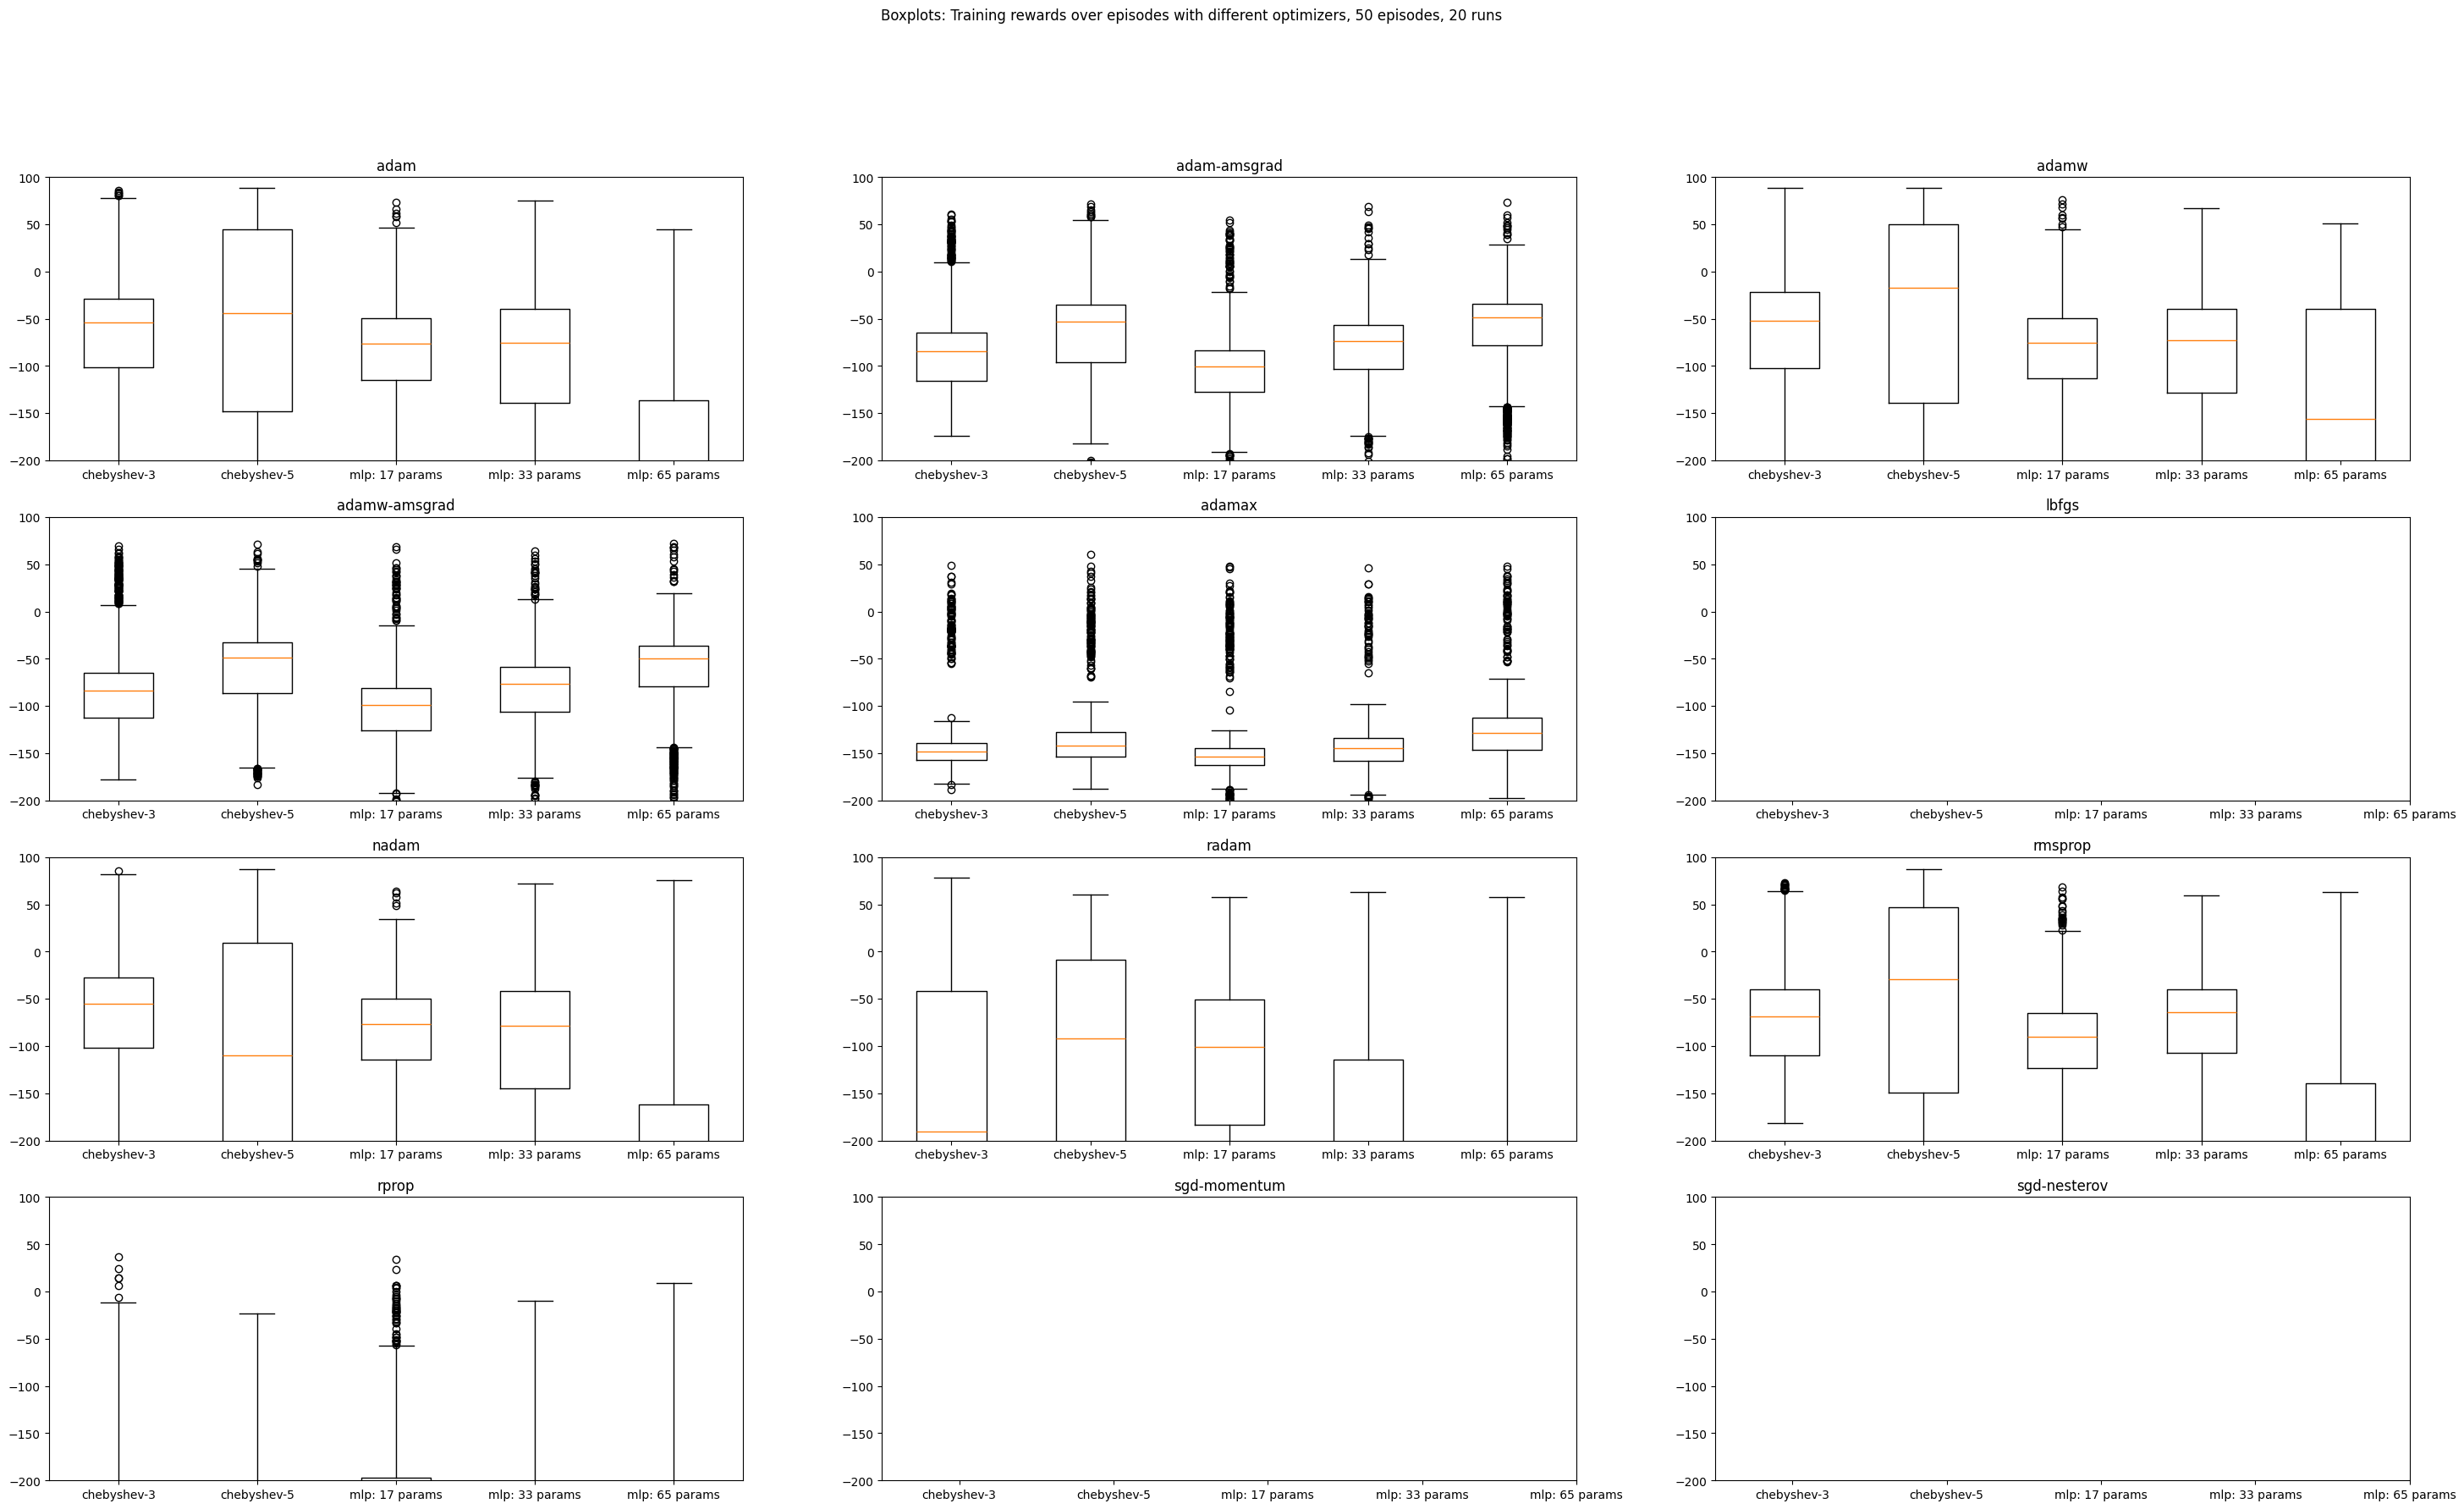

In [35]:
fig, axes = plt.subplots(4, (len(optimizers)+2)//4) 
axes = axes.flatten()
fig.set_figwidth(len(optimizers)*3)
fig.set_figheight(20)
fig.suptitle(f'Boxplots: Training rewards over episodes with different optimizers, {episodes} episodes, {n_runs} runs')

all_results = [reinforce_results_train_optimizers, reinforce_results_train_optimizers_deg5, reinforce_results_train_optimizers_mlp_17, reinforce_results_train_optimizers_mlp_33, reinforce_results_train_optimizers_mlp_65]

for i, _ in enumerate(optimizers):
    ax = axes[i]
    ax.set_title(optimizers[i])
    optim_boxplotdata = []
    for method in all_results:
        try:
            temp_list = []
            for j in range(len(method[i])): 
                try:
                    temp_list.append(method[i][j][1])
                except:
                    pass
            optim_boxplotdata.append(np.concatenate(temp_list))
        except:
            pass
    
    ax.boxplot(optim_boxplotdata)
    ax.set_xticks([1, 2, 3, 4, 5], ['chebyshev-3', 'chebyshev-5', 'mlp: 17 params', 'mlp: 33 params', 'mlp: 65 params'])
    ax.set_ylim([-200, 100])

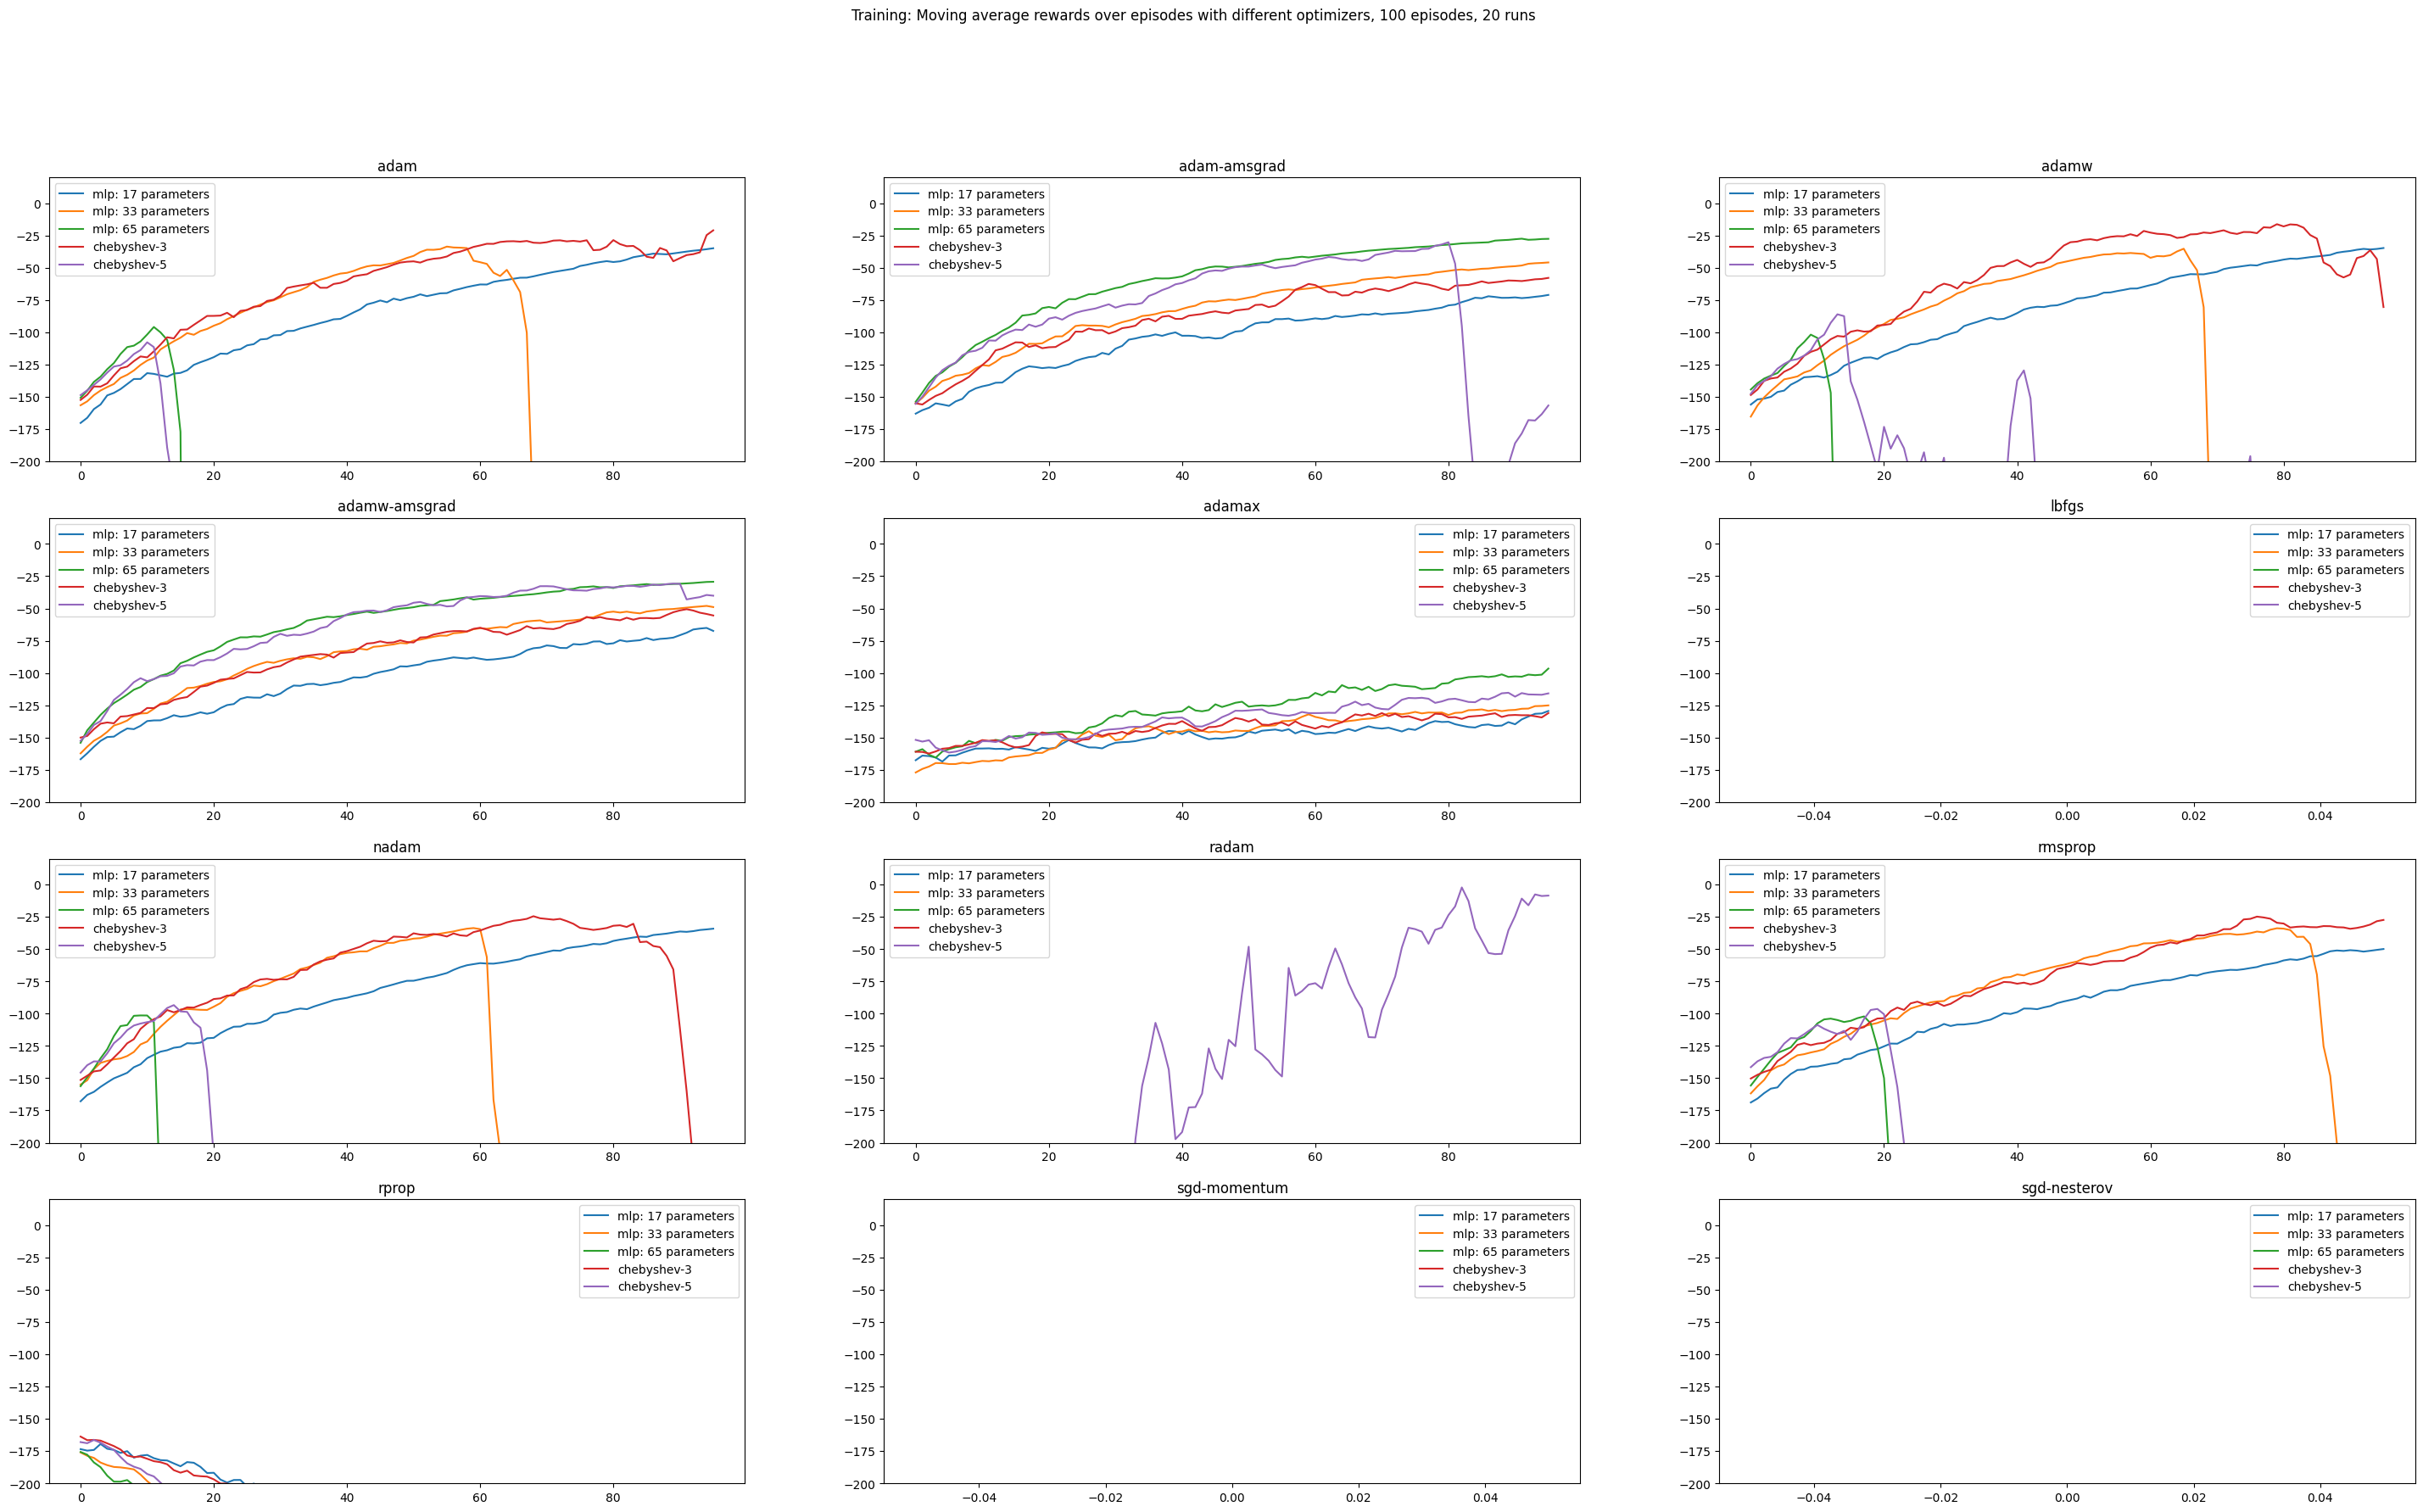

In [19]:
fig, axes = plt.subplots(4, (len(optimizers)+2)//4) 
axes = axes.flatten()
fig.set_figwidth(len(optimizers)*3)
fig.set_figheight(20)
fig.suptitle(f'Training: Moving average rewards over episodes with different optimizers, {episodes} episodes, {n_runs} runs')

for i, opt in enumerate(optimizers):
    ax = axes[i]

    ax.set_title("%s" % optimizers[i])
    #ax.plot(reinforce_results_train_optimizers_mean_rewards_17[i], label='mean reward')
    ax.plot(reinforce_results_train_optimizers_moving_average_rewards_mlp_17[i], label='mlp: 17 parameters')
    ax.plot(reinforce_results_train_optimizers_moving_average_rewards_mlp_33[i], label='mlp: 33 parameters')
    ax.plot(reinforce_results_train_optimizers_moving_average_rewards_mlp_65[i], label='mlp: 65 parameters')
    ax.plot(reinforce_results_train_optimizers_moving_average_rewards[i], label='chebyshev-3')
    ax.plot(reinforce_results_train_optimizers_moving_average_rewards_deg5[i], label='chebyshev-5')
    
    ax.set_ylim([-200, 20])
    ax.legend(loc="best")

### Interpretation

Insights:  
 - rprop, sgd-momentum, sgd-nesterov and lbfgs do not converge  
 - adam, adamw, nadam and radam diverge after some epochs with higher parameter mlps

Our polynomial approximator outperforms the mlp approximator with similar parameter count (17) with all optimiers.  
It also achieves the best overall end reward result throughout optimizers with the radam optimizer.  
 

### Evaluation

In [ ]:
reinforce_results_train_optimizers = db['reinforce_results_train_optimizers']
coeffs, opts = get_converging_coeffs_of_training_results(reinforce_results_train_optimizers, optimizers, n_runs)

In [ ]:
reinforce_results_train_optimizers_deg5 = db['reinforce_results_train_optimizers_deg5']
coeffs_deg5, opts_deg5 = get_converging_coeffs_of_training_results(reinforce_results_train_optimizers_deg5, optimizers, n_runs)

In [ ]:
reinforce_results_train_optimizers_mlp_17 = db['reinforce_results_train_optimizers_mlp_17']
coeffs_mlp_17, opts_mlp_17 = get_converging_coeffs_of_training_results(reinforce_results_train_optimizers_mlp_17, optimizers, n_runs)

In [ ]:
reinforce_results_train_optimizers_mlp_33 = db['reinforce_results_train_optimizers_mlp_33']
coeffs_mlp_33, opts_mlp_33 = get_converging_coeffs_of_training_results(reinforce_results_train_optimizers_mlp_33, optimizers, n_runs)

In [ ]:
reinforce_results_train_optimizers_mlp_65 = db['reinforce_results_train_optimizers_mlp_65']
coeffs_mlp_65, opts_mlp_65 = get_converging_coeffs_of_training_results(reinforce_results_train_optimizers_mlp_65, optimizers, n_runs)

In [19]:
episodes = 50
kwargs_1 = {'episodes': episodes, 'basis': 'mlp', 'mlp_n_hidden_nodes': n_hidden_nodes_1, 'return_coeffs': True}
kwargs_2 = {'episodes': episodes, 'basis': 'mlp', 'mlp_n_hidden_nodes': n_hidden_nodes_2, 'return_coeffs': True}
kwargs_3 = {'episodes': episodes, 'basis': 'mlp', 'mlp_n_hidden_nodes': n_hidden_nodes_3, 'return_coeffs': True}

In [ ]:
pool = parallel.NestablePool(len(coeffs_mlp_17))
reinforce_results_eval_optimizers_mlp_17 = pool.starmap(parallel.job_evaluate_ncoeffs, zip(coeffs_mlp_17, repeat(kwargs_1)))
db['reinforce_results_eval_optimizers_mlp_17'] = reinforce_results_eval_optimizers_mlp_17

In [ ]:
pool = parallel.NestablePool(len(coeffs_mlp_33))
reinforce_results_eval_optimizers_mlp_33 = pool.starmap(parallel.job_evaluate_ncoeffs, zip(coeffs_mlp_33, repeat(kwargs_2)))
db['reinforce_results_eval_optimizers_mlp_33'] = reinforce_results_eval_optimizers_mlp_33

In [ ]:
pool = parallel.NestablePool(len(coeffs_mlp_65))
reinforce_results_eval_optimizers_mlp_65 = pool.starmap(parallel.job_evaluate_ncoeffs, zip(coeffs_mlp_65, repeat(kwargs_3)))
db['reinforce_results_eval_optimizers_mlp_65'] = reinforce_results_eval_optimizers_mlp_65

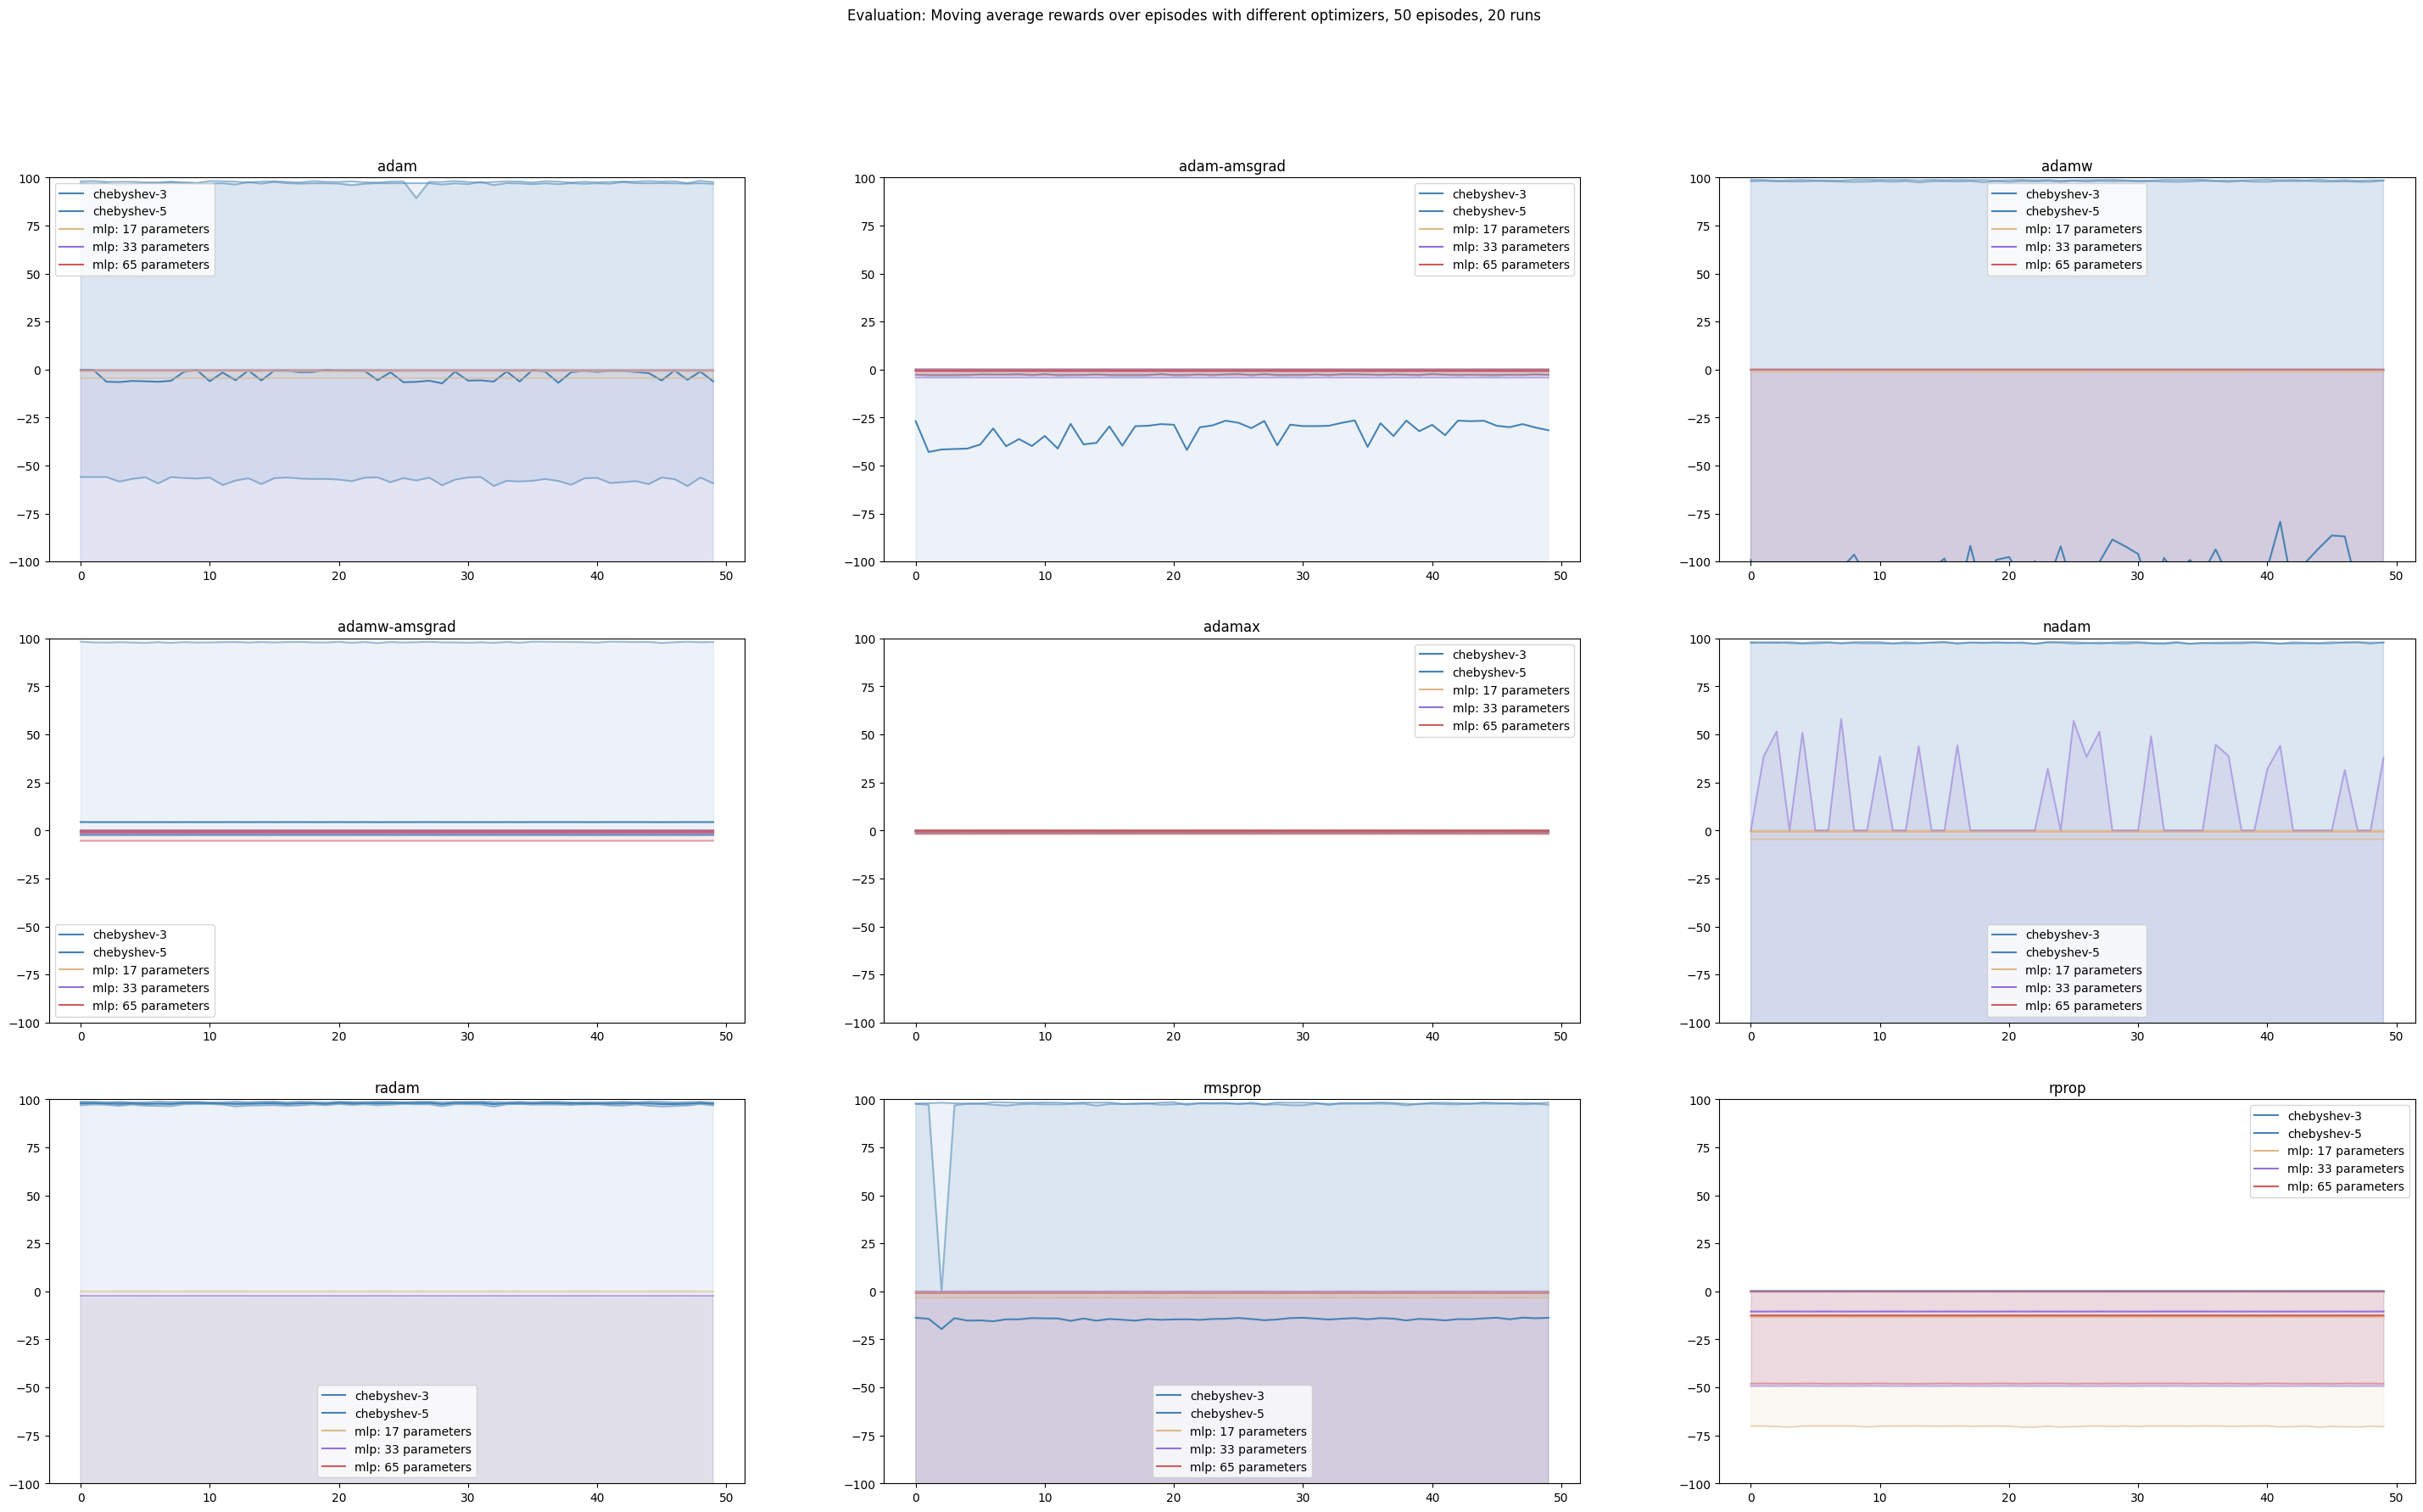

In [26]:
axes_indices = {'adam': 0, 'adam-amsgrad': 1, 'adamw': 2, 'adamw-amsgrad': 3, 'adamax': 4, 'nadam': 5, 'radam': 6, 'rmsprop': 7, 'rprop': 8}

reinforce_results_eval_optimizers = db['reinforce_results_eval_optimizers']
reinforce_results_eval_optimizers_deg5 = db['reinforce_results_eval_optimizers_deg5']
reinforce_results_eval_optimizers_mlp_17 = db['reinforce_results_eval_optimizers_mlp_17']
reinforce_results_eval_optimizers_mlp_33 = db['reinforce_results_eval_optimizers_mlp_33']
reinforce_results_eval_optimizers_mlp_65 = db['reinforce_results_eval_optimizers_mlp_65']

fig, axes = plt.subplots(3, 3) 
axes = axes.flatten()
fig.set_figwidth(len(optimizers)*3)
fig.set_figheight(20)
fig.suptitle(f'Evaluation: Moving average rewards over episodes with different optimizers, {episodes} episodes, {n_runs} runs')

plot_evaluation_min_mean_max_rewards(reinforce_results_eval_optimizers, opts, axes=axes, axes_indices=axes_indices, label='chebyshev-3', color=color_cheby, coeffs_in_results=False)
plot_evaluation_min_mean_max_rewards(reinforce_results_eval_optimizers_deg5, opts, axes=axes, axes_indices=axes_indices, label='chebyshev-5', color=color_cheby)
plot_evaluation_min_mean_max_rewards(reinforce_results_eval_optimizers_mlp_17, opts_mlp_17, axes=axes, axes_indices=axes_indices, label='mlp: 17 parameters', color=color_mlp_17, coeffs_in_results=True)
plot_evaluation_min_mean_max_rewards(reinforce_results_eval_optimizers_mlp_33, opts_mlp_33, axes=axes, axes_indices=axes_indices, label='mlp: 33 parameters', color=color_mlp_33, coeffs_in_results=True)
plot_evaluation_min_mean_max_rewards(reinforce_results_eval_optimizers_mlp_65, opts_mlp_65, axes=axes, axes_indices=axes_indices, label='mlp: 65 parameters', color=color_mlp_65, coeffs_in_results=True)

In [27]:
def get_all_eval_results_per_optimizer(results, optimizers, coeffs_in_results=False):
    ret = {}
    for i, opt in enumerate(optimizers):
        temp_list = []
        for j in range(len(results[i])):
            try:
                if coeffs_in_results:
                    temp_list.append(results[i][j][1])
                else:
                    temp_list.append(results[i][j])
            except:
                pass
        ret[opt] = np.concatenate(temp_list)
    return ret

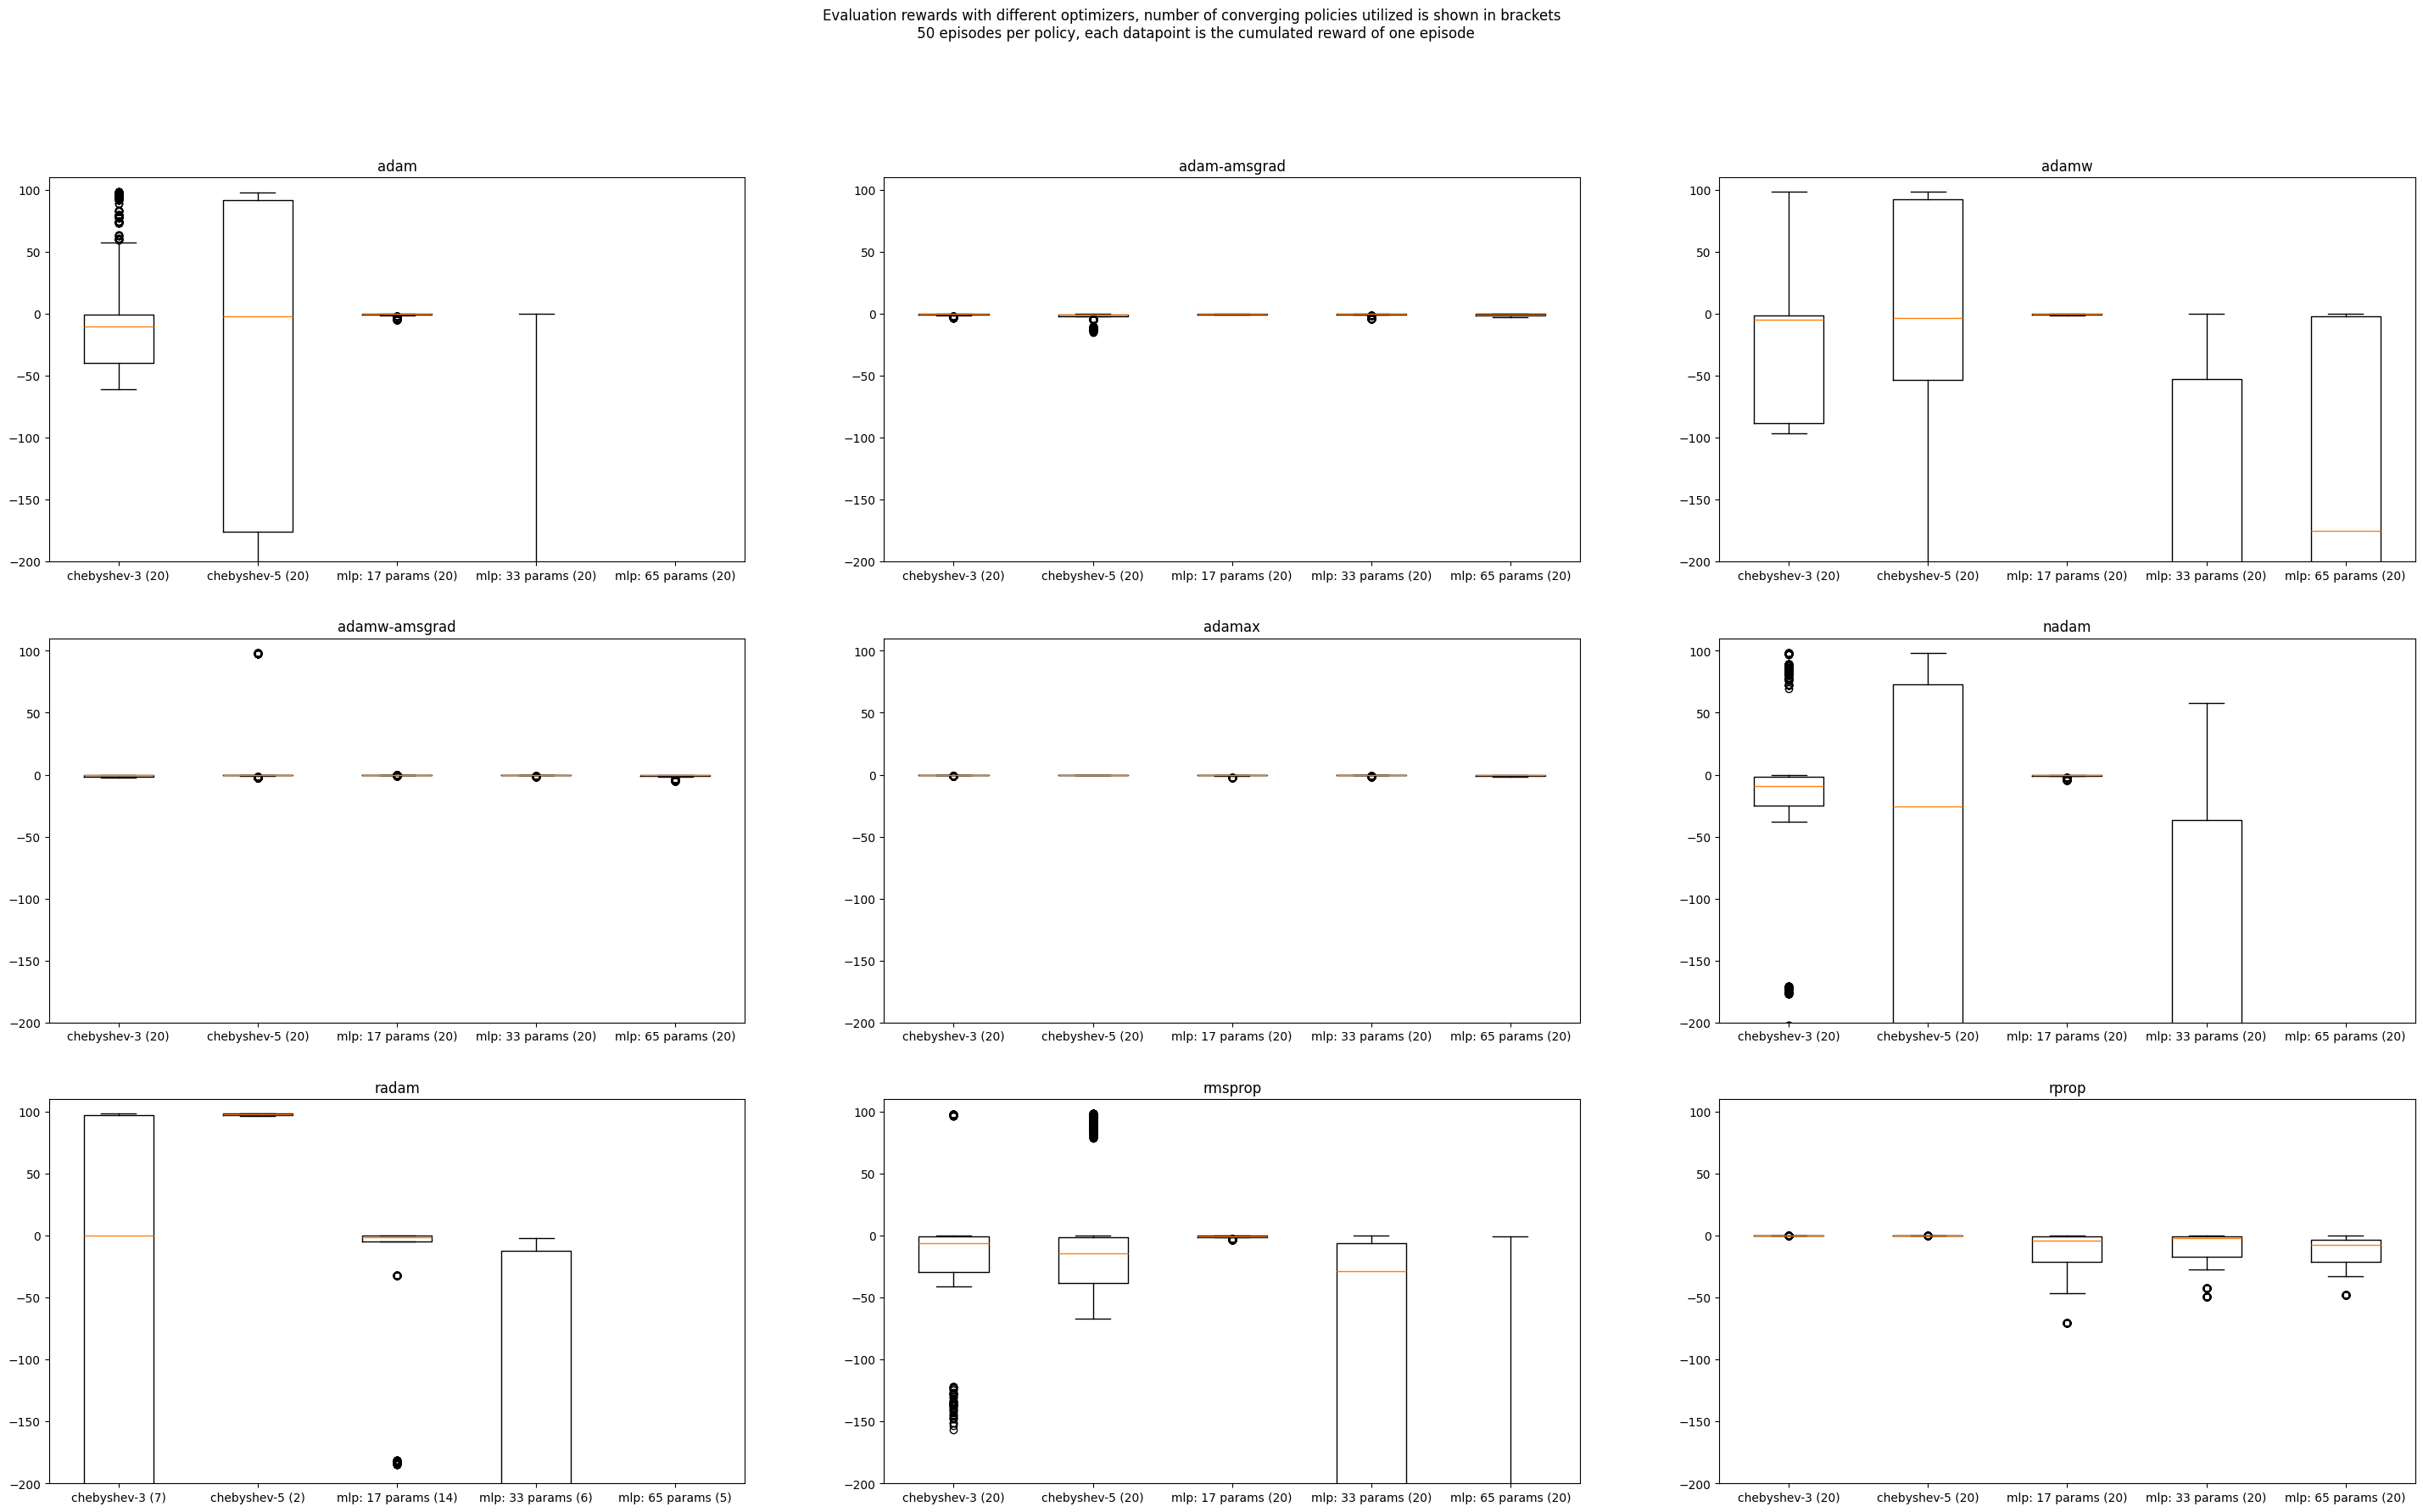

In [28]:
axes_indices = {'adam': 0, 'adam-amsgrad': 1, 'adamw': 2, 'adamw-amsgrad': 3, 'adamax': 4, 'nadam': 5, 'radam': 6, 'rmsprop': 7, 'rprop': 8}

reinforce_results_eval_optimizers = db['reinforce_results_eval_optimizers']
reinforce_results_eval_optimizers_deg5 = db['reinforce_results_eval_optimizers_deg5']
reinforce_results_eval_optimizers_mlp_17 = db['reinforce_results_eval_optimizers_mlp_17']
reinforce_results_eval_optimizers_mlp_33 = db['reinforce_results_eval_optimizers_mlp_33']
reinforce_results_eval_optimizers_mlp_65 = db['reinforce_results_eval_optimizers_mlp_65']

results_chebyshev = get_all_eval_results_per_optimizer(reinforce_results_eval_optimizers, opts)
results_chebyshev_deg5 = get_all_eval_results_per_optimizer(reinforce_results_eval_optimizers_deg5, opts)
results_mlp_17 = get_all_eval_results_per_optimizer(reinforce_results_eval_optimizers_mlp_17, opts_mlp_17, coeffs_in_results=True)
results_mlp_33  = get_all_eval_results_per_optimizer(reinforce_results_eval_optimizers_mlp_33, opts_mlp_33, coeffs_in_results=True)
results_mlp_65  = get_all_eval_results_per_optimizer(reinforce_results_eval_optimizers_mlp_65, opts_mlp_65, coeffs_in_results=True)

dicts = [results_chebyshev, results_chebyshev_deg5, results_mlp_17, results_mlp_33, results_mlp_65]
all_results = {}

for d in dicts:
    for key, value in d.items():
        if key in all_results:
            all_results[key].append(value)
        else:
            all_results[key] = [value]  

fig, axes = plt.subplots(3, 3)
axes = axes.flatten()
fig.set_figwidth(len(optimizers) * 3)
fig.set_figheight(20)
fig.suptitle(f'Evaluation rewards with different optimizers, number of converging policies utilized is shown in brackets \n {episodes} episodes per policy, each datapoint is the cumulated reward of one episode')

for i, opt in enumerate(all_results):
    ax = axes[axes_indices[opt]]
    ax.set_title(opt)
    optim_boxplotdata = []
    num_policies = []
    for j, _ in enumerate(all_results[opt]):
        try:
            optim_boxplotdata.append(all_results[opt][j])
        except:
            pass
        num_policies.append(len(all_results[opt][j])/episodes)
    ax.boxplot(optim_boxplotdata)
    ax.set_xticks([1, 2, 3, 4, 5], [f'chebyshev-3 ({num_policies[0]:.0f})', f'chebyshev-5 ({num_policies[1]:.0f})', f'mlp: 17 params ({num_policies[2]:.0f})', f'mlp: 33 params ({num_policies[3]:.0f})', f'mlp: 65 params ({num_policies[4]:.0f})'])
    ax.set_ylim([-200, 110])

### Interpretation

Insights:  
**Most mlp approximators did not manage to converge to the goal flag, while the polynomial approximator managed to do so with selected optimizers.**  

### Analyze best result

In [ ]:
reinforce_results_eval_optimizers_mlp_33 = db['reinforce_results_eval_optimizers_mlp_33']
best_opt_index, best_opt_run = get_best_candidates_of_evaluation_result(reinforce_results_eval_optimizers_mlp_33)
best_opt_index, best_opt_run 

In [33]:
np.mean(reinforce_results_eval_optimizers_mlp_33[best_opt_index][best_opt_run][1])

-0.0002969410935538538

Interestingly, although nadam with an MLP with 33 is the only result showing tendencies towards reaching the flag, the best solution reward-wise is still one that doesn't converge to the goal flag.  
The one showing the spikes in reward actually compensates positive epsiodes with negative ones:  

In [ ]:
x0s = np.linspace(-0.6, -0.4, 100)
kwargs = {'basis': 'mlp', 'mlp_n_hidden_nodes': n_hidden_nodes_2, 'episodes': 1, 'mu_coeffs': reinforce_results_eval_optimizers_mlp_33[5][0][0]}

results = []

for x in x0s:
    kwargs['start_loc'] = x
    results.append(parallel.job_evaluate(kwargs))

db['mountaincar_reinforce_single_layer_mlp_episode_result'] = results